In [11]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data = pd.read_csv("data/Youthes.csv", sep=";")
print(data.head())
print(f"\nРазмер данных: {len(data)}")

   Возраст  Масса тела.кг  Длина тела.см  Ширина плеч  Ширина таза  \
0       21           71.0          177.0         39.0         27.0   
1       20           96.9          161.0         41.5         32.0   
2       20           95.7          170.0         37.0         34.0   
3       21          103.7          183.0         41.5         35.0   
4       20           93.0          171.0         46.0         34.0   

   ОГК в покое  Размах рук.см  ЧСС в покое  ЧССпосле нагрузки  АДс в покое  \
0         86.0          182.0           59                 58          120   
1        114.0          188.5           84                104          143   
2        112.0          187.0          107                120          179   
3        118.0          187.5           99                110          150   
4        108.5          180.0           66                 96          151   

   АДд в покое  
0           75  
1           63  
2          131  
3           98  
4          100  

Размер 

In [ ]:
X = data[['Длина тела.см', 'Ширина плеч', 'Ширина таза', 'ОГК в покое']]
y = data['Масса тела.кг']

print(f"Признаки: {X.columns.tolist()}")
print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

Признаки: ['Длина тела.см', 'Ширина плеч', 'Ширина таза', 'ОГК в покое']
Размер X: (123, 4)
Размер y: (123,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Контрольная выборка: {len(X_test)}")

Обучающая выборка: 98
Контрольная выборка: 25


In [ ]:
# Регрессионное дерево на исходных признаках
regressor = DecisionTreeRegressor(random_state=42, max_depth=5)
regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

errors = y_pred - y_test
std_dev = np.std(errors)

print(f"Стандартное отклонение разницы (исходные признаки): {std_dev:.3f}")
print(f"Средняя ошибка: {np.mean(errors):.3f}")
print(f"MAE: {np.mean(np.abs(errors)):.3f}")

Стандартное отклонение разницы (исходные признаки): 7.311
Средняя ошибка: -0.994
MAE: 5.874


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(f"Объясненная дисперсия: {pca.explained_variance_ratio_}")
print(f"Суммарная: {sum(pca.explained_variance_ratio_):.3f}")

X_pca_train, X_pca_test, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, random_state=42)

Объясненная дисперсия: [0.52261607 0.21270507 0.1663119 ]
Суммарная: 0.902


In [8]:
# Регрессионное дерево на PCA-признаках
regressor_pca = DecisionTreeRegressor(random_state=42, max_depth=5)
regressor_pca.fit(X_pca_train, y_train_pca)

y_pred_pca = regressor_pca.predict(X_pca_test)

errors_pca = y_pred_pca - y_test_pca
std_dev_pca = np.std(errors_pca)

print(f"Стандартное отклонение разницы (PCA признаки): {std_dev_pca:.3f}")
print(f"Средняя ошибка: {np.mean(errors_pca):.3f}")
print(f"MAE: {np.mean(np.abs(errors_pca)):.3f}")

Стандартное отклонение разницы (PCA признаки): 6.730
Средняя ошибка: -4.918
MAE: 7.015


Исходные признаки: STD = 7.311
PCA признаки (3 компоненты): STD = 6.730
Разница: 0.581

PCA сохранил 90.16% дисперсии данных
Возможно, потеря информации привела к ухудшению/улучшению предсказания
Антропометрические признаки коррелируют, PCA мог сжать избыточность

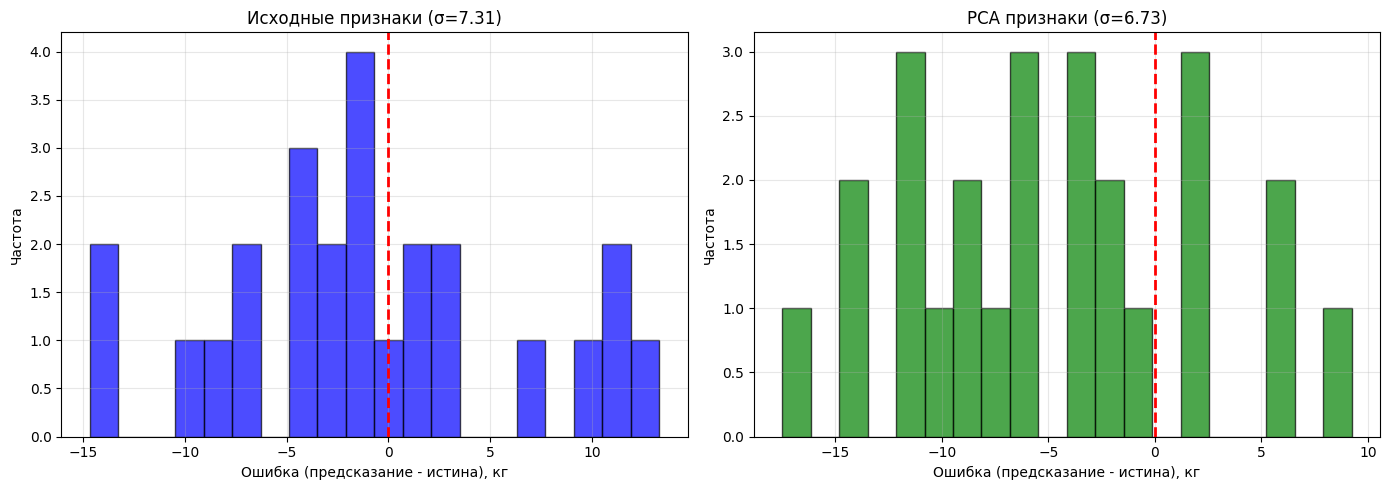

In [12]:
# Гистограмма ошибок предсказания
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(errors, bins=20, alpha=0.7, edgecolor='black', color='blue')
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Ошибка (предсказание - истина), кг')
axes[0].set_ylabel('Частота')
axes[0].set_title(f'Исходные признаки (σ={std_dev:.2f})')
axes[0].grid(True, alpha=0.3)

axes[1].hist(errors_pca, bins=20, alpha=0.7, edgecolor='black', color='green')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Ошибка (предсказание - истина), кг')
axes[1].set_ylabel('Частота')
axes[1].set_title(f'PCA признаки (σ={std_dev_pca:.2f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()